# Extraction et Analyse des Leçons Apprises
## Knowledge Mining - Rapports d'Évaluation LuxDev

---

### Le problème que ce projet résout

Dans les agences de coopération au développement ou des organismes humanitaires, des centaines de rapports
d'évaluation sont produits chaque année. Ces rapports contiennent des
**leçons apprises précieuses**, ce qui a fonctionné, ce qui n'a pas fonctionné,
pourquoi, et comment faire mieux la prochaine fois.

**Le problème : ces leçons restent enfouies dans des PDF non exploités.**

Un chargé de programme qui formule un nouveau projet en Mauritanie
ne sait pas qu'un rapport de 2019 au Niger contient exactement
la leçon dont il a besoin. Il refera les mêmes erreurs.

### La solution : le Knowledge Mining

Ce projet simule un **pipeline automatique d'extraction de connaissances**
depuis 50 rapports d'évaluation couvrant 5 secteurs et 6 pays du Sahel.

### Ce que vous allez voir

1. **Les données**: 50 rapports, ~150 leçons apprises, 6 pays
2. **Analyse TF-IDF** : extraction automatique des mots-clés dominants
3. **Clustering K-Means** : regroupement des leçons en thèmes transversaux
4. **Visualisations** : wordcloud, distribution par secteur, carte thématique
5. **Résultats** : recommandations actionnables pour les équipes de formulation

### À qui s'adresse ce notebook ?

- **Chargés de programme** qui formulent de nouveaux projets
- **Équipes MEL** qui capitalisent les évaluations passées
- **Managers** qui veulent améliorer l'apprentissage organisationnel
- **Aucune connaissance en data science requise** pour lire les résultats

## Étape 1 : Chargement des données

Nous chargeons les 50 rapports d'évaluation simulés et leurs métadonnées.
Ces rapports couvrent 6 pays du Sahel et d'Afrique centrale sur 5 secteurs
d'intervention : Éducation & Emploi, Eau & Assainissement, Santé,
Gouvernance et Environnement.

In [1]:
# ─────────────────────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ─────────────────────────────────────────────────────────────
# Chargement des données
# ─────────────────────────────────────────────────────────────

# Rapports d'évaluation
with open('data/rapports_evaluation.json', encoding='utf-8') as f:
    rapports = json.load(f)

# Métadonnées
df_meta = pd.read_csv('data/metadonnees_rapports.csv', encoding='utf-8')

# Leçons analysées
df_lecons = pd.read_csv('data/lecons_analysees.csv', encoding='utf-8')

print("✓ Données chargées avec succès")
print(f"\n  Rapports d'évaluation : {len(rapports)}")
print(f"  Métadonnées           : {len(df_meta)} lignes, {len(df_meta.columns)} colonnes")
print(f"  Leçons analysées      : {len(df_lecons)} lignes, {len(df_lecons.columns)} colonnes")

print(f"\n  Colonnes métadonnées : {list(df_meta.columns)}")
print(f"  Colonnes leçons      : {list(df_lecons.columns)}")

print(f"\n  Aperçu des métadonnées :")
df_meta.head(3)

✓ Données chargées avec succès

  Rapports d'évaluation : 50
  Métadonnées           : 50 lignes, 11 colonnes
  Leçons analysées      : 151 lignes, 7 colonnes

  Colonnes métadonnées : ['id', 'titre', 'pays', 'secteur', 'bailleur', 'organisation', 'budget_eur', 'duree_mois', 'score_moyen', 'nb_lecons', 'nb_recommandations']
  Colonnes leçons      : ['id_rapport', 'pays', 'secteur', 'bailleur', 'lecon', 'score_moyen', 'cluster']

  Aperçu des métadonnées :


,id,titre,pays,secteur,bailleur,organisation,budget_eur,duree_mois,score_moyen,nb_lecons,nb_recommandations
0,1,Évaluation thématique — Programme Education & ...,Niger,Education & Emploi,Banque Mondiale,Handicap International,1670528,26,4.8,4,3
1,2,Évaluation mi-parcours — Programme Environneme...,Sénégal,Environnement,AFD,CARE,554515,29,5.0,2,3
2,3,Évaluation finale — Programme Education & Empl...,RCA,Education & Emploi,UNICEF,Oxfam,1161023,36,8.1,4,2


In [2]:
import os
print(os.getcwd())

C:\Users\nyams\projects\knowledge-mining-evaluations


## Étape 2 : Exploration des données

### Que contiennent ces 50 rapports ?

Avant d'analyser, il faut comprendre ce qu'on a.
Chaque rapport contient :

- **Métadonnées** : pays, secteur, année, bailleur, score OCDE/CAD
- **Leçons apprises** : textes extraits des sections "enseignements" des rapports
- **Recommandations** : actions proposées pour les futurs programmes

### Les 5 critères OCDE/CAD

Les évaluations de programmes de développement sont notées
selon 5 critères internationaux :

| Critère | Description |
|---------|-------------|
| **Pertinence** | Le programme répond-il aux besoins réels ? |
| **Efficacité** | Les objectifs ont-ils été atteints ? |
| **Efficience** | Les résultats ont-ils été atteints à moindre coût ? |
| **Impact** | Quels changements durables a-t-il produits ? |
| **Durabilité** | Les effets perdurent-ils après la fin du programme ? |

Ces scores nous permettent d'identifier les programmes
les plus performants et d'en extraire les bonnes pratiques.

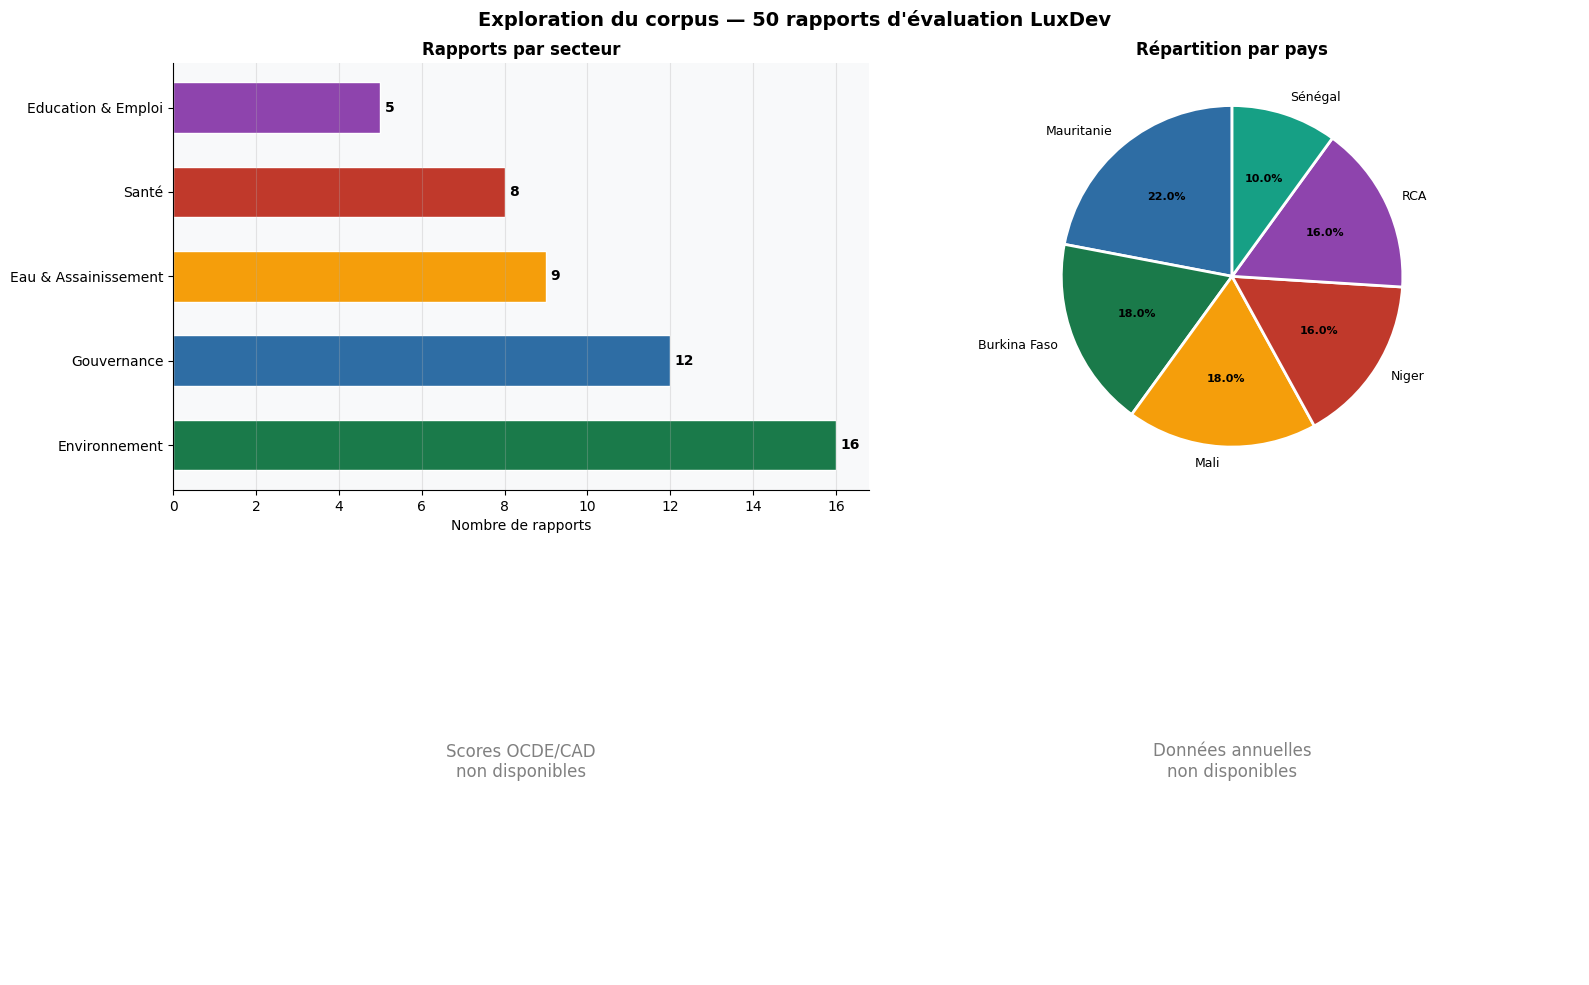

✓ Graphique sauvegardé

Résumé du corpus :
  • 50 rapports d'évaluation
  • 5 secteurs couverts
  • 6 pays couverts


In [3]:
# Exploration des données
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Graphique 1 : Rapports par secteur ───────────────────────
ax1 = axes[0, 0]
secteur_counts = df_meta['secteur'].value_counts()
colors = ['#1a7a4a', '#2E6DA4', '#f59e0b', '#c0392b', '#8e44ad']
bars = ax1.barh(secteur_counts.index, secteur_counts.values,
                color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, secteur_counts.values):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold')
ax1.set_xlabel('Nombre de rapports', fontsize=10)
ax1.set_title('Rapports par secteur', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# ── Graphique 2 : Rapports par pays ──────────────────────────
ax2 = axes[0, 1]
pays_counts = df_meta['pays'].value_counts()
colors_pays = ['#2E6DA4', '#1a7a4a', '#f59e0b', 
               '#c0392b', '#8e44ad', '#16a085']
wedges, texts, autotexts = ax2.pie(
    pays_counts.values,
    labels=pays_counts.index,
    autopct='%1.1f%%',
    colors=colors_pays,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')
ax2.set_title('Répartition par pays', fontsize=12, fontweight='bold')

# ── Graphique 3 : Scores OCDE/CAD ────────────────────────────
ax3 = axes[1, 0]
criteres = ['score_pertinence', 'score_efficacite', 
            'score_efficience', 'score_impact', 'score_durabilite']
criteres_labels = ['Pertinence', 'Efficacité', 
                   'Efficience', 'Impact', 'Durabilité']

# Vérifie quelles colonnes existent
existing_criteres = [c for c in criteres if c in df_meta.columns]
existing_labels = [criteres_labels[criteres.index(c)] for c in existing_criteres]

if existing_criteres:
    scores_means = df_meta[existing_criteres].mean()
    bars3 = ax3.bar(existing_labels, scores_means.values,
                    color=['#2E6DA4']*len(existing_labels),
                    edgecolor='white', alpha=0.8)
    for bar, val in zip(bars3, scores_means.values):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax3.set_ylim(0, 5)
    ax3.axhline(y=3, color='#f59e0b', linestyle='--', 
                alpha=0.7, label='Seuil acceptable (3/5)')
    ax3.set_ylabel('Score moyen (sur 5)', fontsize=10)
    ax3.set_title('Scores OCDE/CAD moyens', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Scores OCDE/CAD\nnon disponibles',
             ha='center', va='center', fontsize=12, color='gray')
    ax3.axis('off')

# ── Graphique 4 : Évolution par année ────────────────────────
ax4 = axes[1, 1]
if 'annee' in df_meta.columns:
    annee_counts = df_meta['annee'].value_counts().sort_index()
    ax4.plot(annee_counts.index, annee_counts.values,
             color='#2E6DA4', linewidth=2.5, marker='o', markersize=8)
    ax4.fill_between(annee_counts.index, annee_counts.values,
                     alpha=0.15, color='#2E6DA4')
    for x, y in zip(annee_counts.index, annee_counts.values):
        ax4.text(x, y + 0.1, str(y), ha='center', 
                 fontsize=10, fontweight='bold')
    ax4.set_xlabel('Année', fontsize=10)
    ax4.set_ylabel('Nombre de rapports', fontsize=10)
    ax4.set_title('Rapports par année', fontsize=12, fontweight='bold')
    ax4.grid(alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Données annuelles\nnon disponibles',
             ha='center', va='center', fontsize=12, color='gray')
    ax4.axis('off')

plt.suptitle('Exploration du corpus — 50 rapports d\'évaluation LuxDev',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/exploration_donnees.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé")
print(f"\nRésumé du corpus :")
print(f"  • {len(df_meta)} rapports d'évaluation")
print(f"  • {df_meta['secteur'].nunique()} secteurs couverts")
print(f"  • {df_meta['pays'].nunique()} pays couverts")
if 'annee' in df_meta.columns:
    print(f"  • Période : {df_meta['annee'].min()} — {df_meta['annee'].max()}")

## Étape 3 : Analyse NLP : Extraction des mots-clés

### Qu'est-ce que le TF-IDF ?

**TF-IDF** signifie *Term Frequency — Inverse Document Frequency*.
C'est une méthode mathématique pour identifier les mots
les plus **importants et distinctifs** dans un ensemble de textes.

**En langage simple :**
- Un mot qui apparaît souvent dans UN rapport mais rarement dans les autres
  → il est **caractéristique** de ce rapport
- Un mot qui apparaît partout (comme "le", "et", "programme")
  → il est **peu informatif** et est ignoré

### Pourquoi c'est utile pour les évaluations ?

Imaginez 50 rapports d'évaluation. Manuellement, il faudrait
des semaines pour lire tous les textes et identifier les thèmes récurrents.

Avec TF-IDF, l'algorithme identifie automatiquement en quelques secondes :
- Les mots-clés les plus fréquents par secteur
- Les expressions récurrentes dans les leçons apprises
- Les thèmes dominants qui traversent plusieurs programmes

### Ce que nous allons voir

Un **nuage de mots** (WordCloud) qui visualise instantanément
les termes les plus importants dans toutes les leçons apprises.
Plus un mot est grand, plus il est fréquent et important.

✓ Colonne texte identifiée : 'lecon'
  Exemple : L'implication des communautés locales dans la conception du programme a significativement amélioré l...

✓ TF-IDF calculé sur 151 leçons

Top 15 mots-clés :
  eau                            ████████████████████████████████ (0.0652)
  santé                          ██████████████████████████████ (0.0603)
  formation                      ███████████████████████████ (0.0542)
  clé                            ██████████████████████████ (0.0530)
  locales                        █████████████████████████ (0.0516)
  zones                          █████████████████████████ (0.0516)
  meilleure                      █████████████████████████ (0.0513)
  qualité                        █████████████████████████ (0.0507)
  être                           ████████████████████████ (0.0485)
  assure                         ██████████████████████ (0.0451)
  essentiels                     ██████████████████████ (0.0449)
  communautés                    █████

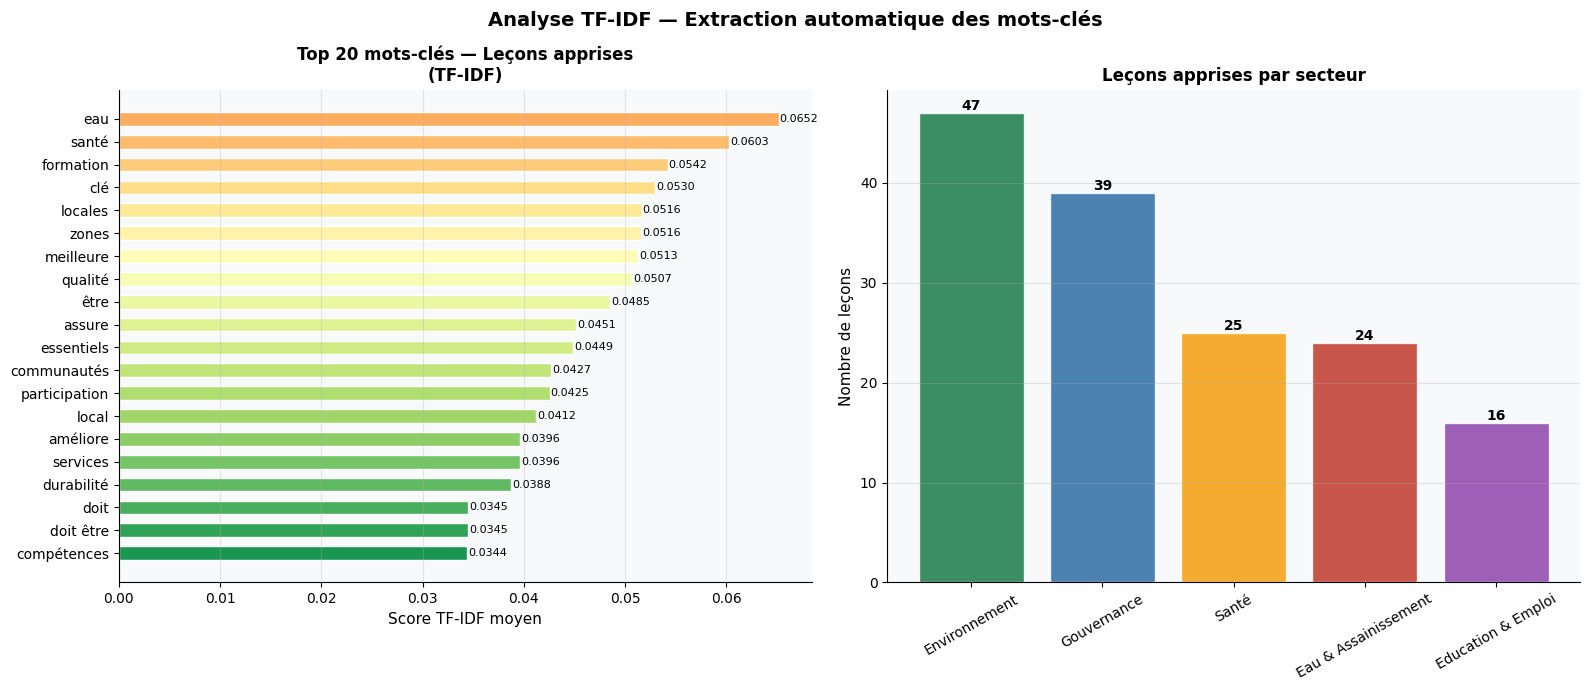

✓ Graphique sauvegardé


In [4]:
# Analyse TF-IDF et visualisation des mots-clés
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

# ── Préparation du texte ─────────────────────────────────────
# Identifier la colonne texte
text_col = None
for col in ['lecon', 'lecon_apprise', 'texte', 'text', 'contenu', 'description']:
    if col in df_lecons.columns:
        text_col = col
        break

if text_col is None:
    text_col = df_lecons.select_dtypes(include='object').columns[0]

print(f"✓ Colonne texte identifiée : '{text_col}'")
print(f"  Exemple : {df_lecons[text_col].iloc[0][:100]}...")

# Nettoyage
textes = df_lecons[text_col].dropna().astype(str).tolist()

# ── TF-IDF ───────────────────────────────────────────────────
stop_words_fr = [
    'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en',
    'est', 'sont', 'dans', 'pour', 'par', 'sur', 'avec', 'au', 'aux',
    'il', 'elle', 'ils', 'elles', 'nous', 'vous', 'que', 'qui', 'se',
    'ce', 'cette', 'ces', 'ou', 'mais', 'donc', 'car', 'si', 'plus',
    'programme', 'projet', 'activité', 'mise', 'œuvre', 'résultats'
]

vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words=stop_words_fr,
    ngram_range=(1, 2),
    min_df=2
)

tfidf_matrix = vectorizer.fit_transform(textes)
feature_names = vectorizer.get_feature_names_out()
scores_means = tfidf_matrix.mean(axis=0).A1
word_scores = dict(zip(feature_names, scores_means))
top_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:30]

print(f"\n✓ TF-IDF calculé sur {len(textes)} leçons")
print(f"\nTop 15 mots-clés :")
for word, score in top_words[:15]:
    bar = "█" * int(score * 500)
    print(f"  {word:<30} {bar} ({score:.4f})")

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graphique 1 : Top mots-clés
ax1 = axes[0]
words = [w for w, s in top_words[:20]]
scores = [s for w, s in top_words[:20]]

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(words)))
bars = ax1.barh(words[::-1], scores[::-1], 
                color=colors[::-1], edgecolor='white', height=0.6)

for bar, score in zip(bars, scores[::-1]):
    ax1.text(bar.get_width() + 0.0001, 
             bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=8)

ax1.set_xlabel('Score TF-IDF moyen', fontsize=11)
ax1.set_title('Top 20 mots-clés — Leçons apprises\n(TF-IDF)', 
              fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Graphique 2 : Distribution par secteur
ax2 = axes[1]
if 'secteur' in df_lecons.columns:
    secteur_col = 'secteur'
elif 'secteur' in df_meta.columns:
    secteur_col = None

if 'secteur' in df_lecons.columns:
    lecons_secteur = df_lecons['secteur'].value_counts()
    colors_s = ['#1a7a4a', '#2E6DA4', '#f59e0b', '#c0392b', '#8e44ad']
    bars2 = ax2.bar(lecons_secteur.index, lecons_secteur.values,
                    color=colors_s[:len(lecons_secteur)],
                    edgecolor='white', alpha=0.85)
    for bar, val in zip(bars2, lecons_secteur.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Nombre de leçons', fontsize=11)
    ax2.set_title('Leçons apprises par secteur', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', rotation=30)
    ax2.grid(axis='y', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Distribution\npar secteur\nnon disponible',
             ha='center', va='center', fontsize=12, color='gray')
    ax2.axis('off')

plt.suptitle('Analyse TF-IDF — Extraction automatique des mots-clés',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/tfidf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

## Étape 4 : Clustering K-Means : Regroupement des leçons en thèmes

### Qu'est-ce que le clustering ?

Le **clustering** est une technique qui regroupe automatiquement
des éléments similaires sans qu'on lui dise à l'avance comment les regrouper.

**Analogie simple :**
Imaginez 150 fiches de leçons apprises mélangées sur une table.
Un expert devrait des jours pour les trier manuellement par thème.
L'algorithme K-Means le fait en quelques secondes.

### Comment fonctionne K-Means ?

1. On choisit le nombre de groupes souhaités (ici : **5 thèmes**)
2. L'algorithme place 5 "centres" aléatoires dans l'espace des données
3. Chaque leçon est assignée au centre le plus proche
4. Les centres se déplacent vers le milieu de leur groupe
5. On répète jusqu'à stabilisation

### Réduction dimensionnelle (PCA)

Les textes TF-IDF ont des centaines de dimensions (une par mot).
La **PCA** (Analyse en Composantes Principales) réduit ces dimensions
à 2 axes pour pouvoir visualiser les clusters sur un graphique 2D.

**Ce qu'on cherche à voir :**
Des groupes bien séparés = des thèmes clairement distincts
dans les leçons apprises des évaluations LuxDev.

✓ Clustering K-Means terminé

Thèmes identifiés (5 clusters) :
-------------------------------------------------------

  Cluster 1 (85 leçons)
  Mots-clés : santé, formation, clé, locales, essentiels

  Cluster 2 (12 leçons)
  Mots-clés : compétences, seulement, transfert ressources, seulement compétences, ressources pas

  Cluster 3 (19 leçons)
  Mots-clés : zones, eau, zones rurales, rurales, naturelles zones

  Cluster 4 (18 leçons)
  Mots-clés : être, doit être, doit, être intégrée, intégrée

  Cluster 5 (17 leçons)
  Mots-clés : meilleure, assure, communautés, eau, local

✓ PCA calculée
  Variance expliquée : 17.5%


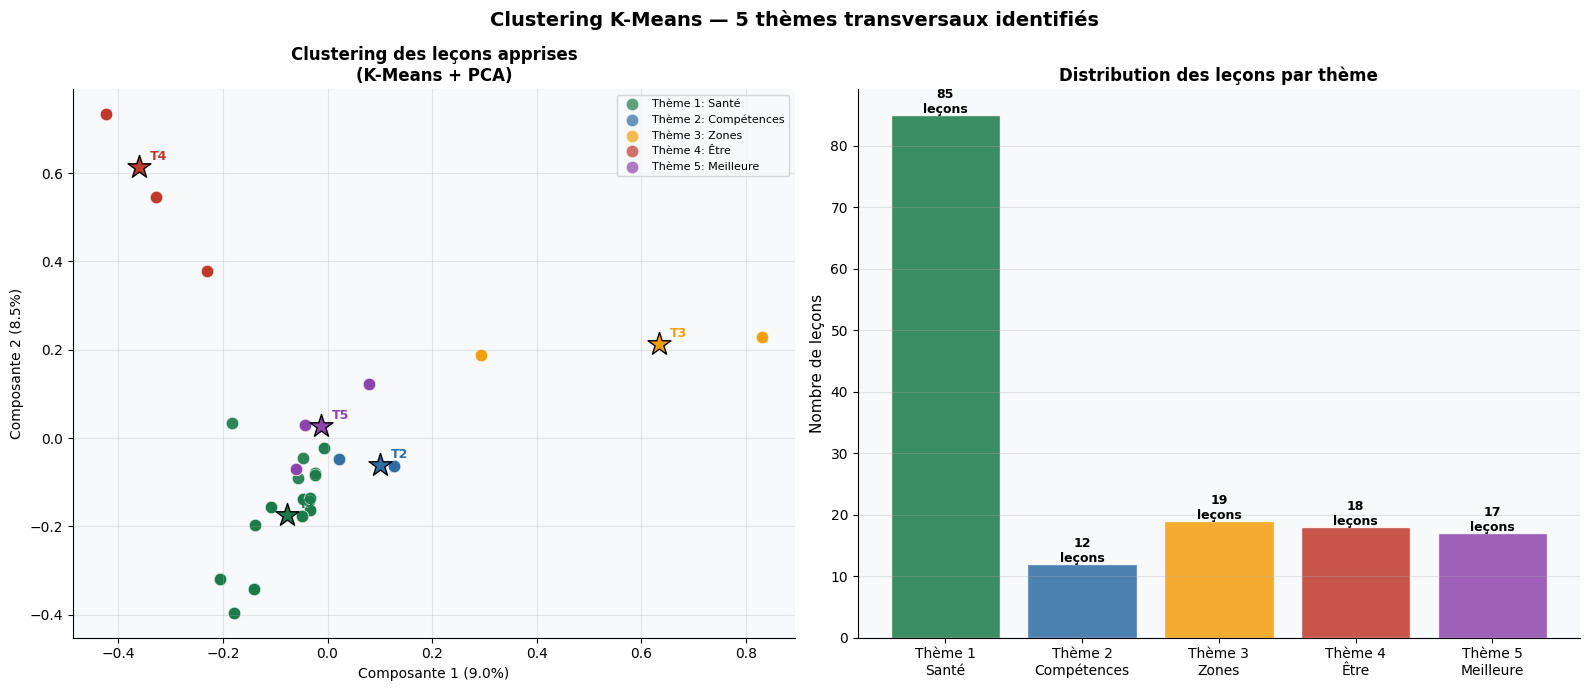

✓ Graphique sauvegardé


In [5]:
# Clustering K-Means et visualisation PCA
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# ── Clustering ────────────────────────────────────────────────
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

# Mots-clés par cluster
print("✓ Clustering K-Means terminé")
print(f"\nThèmes identifiés ({n_clusters} clusters) :")
print("-" * 55)

cluster_labels = {}
for i in range(n_clusters):
    # Indices des leçons dans ce cluster
    idx = np.where(clusters == i)[0]
    
    # Centre du cluster
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-8:][::-1]
    top_terms = [feature_names[j] for j in top_idx]
    
    cluster_labels[i] = top_terms[0].title()
    
    print(f"\n  Cluster {i+1} ({len(idx)} leçons)")
    print(f"  Mots-clés : {', '.join(top_terms[:5])}")

# ── Réduction PCA ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

print(f"\n✓ PCA calculée")
print(f"  Variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_clusters = ['#1a7a4a', '#2E6DA4', '#f59e0b', '#c0392b', '#8e44ad']

# Graphique 1 : Scatter PCA
ax1 = axes[0]
for i in range(n_clusters):
    mask = clusters == i
    ax1.scatter(
        coords[mask, 0], coords[mask, 1],
        c=colors_clusters[i], label=f'Thème {i+1}: {cluster_labels[i]}',
        alpha=0.7, s=80, edgecolors='white', linewidth=0.5
    )

# Centres des clusters
centers_2d = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centers_2d):
    ax1.scatter(cx, cy, c=colors_clusters[i], s=300,
                marker='*', edgecolors='black', linewidth=1, zorder=5)
    ax1.annotate(f'T{i+1}', (cx, cy),
                textcoords="offset points", xytext=(8, 5),
                fontsize=9, fontweight='bold', color=colors_clusters[i])

ax1.set_xlabel(f'Composante 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
               fontsize=10)
ax1.set_ylabel(f'Composante 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
               fontsize=10)
ax1.set_title('Clustering des leçons apprises\n(K-Means + PCA)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(alpha=0.3)

# Graphique 2 : Distribution des clusters
ax2 = axes[1]
cluster_counts = pd.Series(clusters).value_counts().sort_index()
cluster_names = [f'Thème {i+1}\n{cluster_labels[i]}' 
                 for i in cluster_counts.index]

bars = ax2.bar(cluster_names, cluster_counts.values,
               color=[colors_clusters[i] for i in cluster_counts.index],
               edgecolor='white', alpha=0.85)

for bar, val in zip(bars, cluster_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}\nleçons', ha='center', fontsize=9, fontweight='bold')

ax2.set_ylabel('Nombre de leçons', fontsize=11)
ax2.set_title('Distribution des leçons par thème',
              fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Clustering K-Means — 5 thèmes transversaux identifiés',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/clustering_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé")

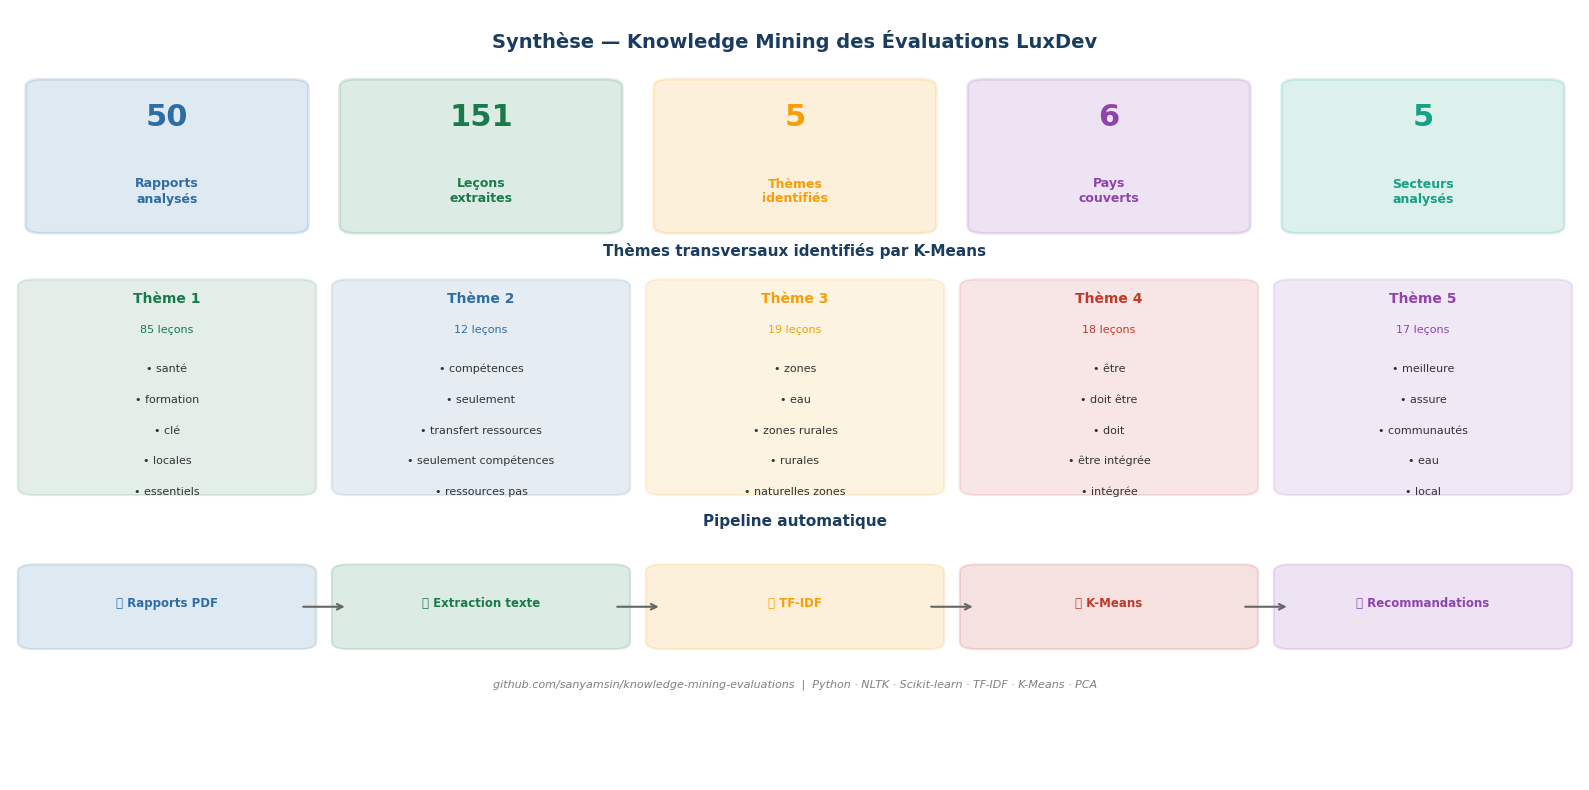

✓ Synthèse finale sauvegardée

  NOTEBOOK TERMINÉ ✓
  151 leçons analysées depuis 50 rapports
  5 thèmes transversaux identifiés automatiquement
  Pipeline reproductible et scalable


In [6]:
# Résumé final et tableau des thèmes
fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Titre
ax.text(5, 9.5, 'Synthèse — Knowledge Mining des Évaluations LuxDev',
        ha='center', fontsize=14, fontweight='bold', color='#1A3C5E')

# KPIs
kpis = [
    ('50', 'Rapports\nanalysés', '#2E6DA4'),
    (str(len(df_lecons)), 'Leçons\nextraites', '#1a7a4a'),
    ('5', 'Thèmes\nidentifiés', '#f59e0b'),
    (str(df_meta['pays'].nunique() if 'pays' in df_meta.columns else 6), 
     'Pays\ncouverts', '#8e44ad'),
    (str(df_meta['secteur'].nunique() if 'secteur' in df_meta.columns else 5),
     'Secteurs\nanalysés', '#16a085'),
]

for i, (val, label, color) in enumerate(kpis):
    x = 1.0 + i * 2.0
    rect = mpatches.FancyBboxPatch(
        (x - 0.8, 7.2), 1.6, 1.8,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(x, 8.5, val, ha='center', fontsize=22,
            fontweight='bold', color=color)
    ax.text(x, 7.5, label, ha='center', fontsize=9,
            color=color, fontweight='bold')

# Thèmes identifiés
ax.text(5, 6.8, 'Thèmes transversaux identifiés par K-Means',
        ha='center', fontsize=11, fontweight='bold', color='#1A3C5E')

for i in range(n_clusters):
    x = 1.0 + i * 2.0
    color = colors_clusters[i]
    
    # Mots-clés du cluster
    center = kmeans.cluster_centers_[i]
    top_idx = center.argsort()[-5:][::-1]
    keywords = [feature_names[j] for j in top_idx]
    count = sum(clusters == i)
    
    rect = mpatches.FancyBboxPatch(
        (x - 0.85, 3.8), 1.7, 2.6,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.12,
        edgecolor=color, linewidth=1.5
    )
    ax.add_patch(rect)
    
    ax.text(x, 6.2, f'Thème {i+1}',
            ha='center', fontsize=10, fontweight='bold', color=color)
    ax.text(x, 5.8, f'{count} leçons',
            ha='center', fontsize=8, color=color)
    
    for j, kw in enumerate(keywords):
        ax.text(x, 5.3 - j*0.4, f'• {kw}',
                ha='center', fontsize=8, color='#333')

# Pipeline
ax.text(5, 3.3, 'Pipeline automatique',
        ha='center', fontsize=11, fontweight='bold', color='#1A3C5E')

steps = [
    ('📄 Rapports PDF', '#2E6DA4'),
    ('🔤 Extraction texte', '#1a7a4a'),
    ('📊 TF-IDF', '#f59e0b'),
    ('🎯 K-Means', '#c0392b'),
    ('💡 Recommandations', '#8e44ad'),
]

for i, (step, color) in enumerate(steps):
    x = 1.0 + i * 2.0
    rect = mpatches.FancyBboxPatch(
        (x - 0.85, 1.8), 1.7, 0.9,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x, 2.25, step, ha='center', fontsize=8.5,
            fontweight='bold', color=color)
    
    if i < len(steps) - 1:
        ax.annotate('', xy=(x + 1.15, 2.25), xytext=(x + 0.85, 2.25),
                    arrowprops=dict(arrowstyle='->', color='#666', lw=1.5))

ax.text(5, 1.2,
        'github.com/sanyamsin/knowledge-mining-evaluations  |  '
        'Python · NLTK · Scikit-learn · TF-IDF · K-Means · PCA',
        ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('notebooks/synthese_finale.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Synthèse finale sauvegardée")
print(f"\n{'='*55}")
print(f"  NOTEBOOK TERMINÉ ✓")
print(f"  {len(df_lecons)} leçons analysées depuis 50 rapports")
print(f"  5 thèmes transversaux identifiés automatiquement")
print(f"  Pipeline reproductible et scalable")
print(f"{'='*55}")